In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import io

In [4]:
url = 'https://raw.githubusercontent.com/ufcg-lsd/radix/radix-sort/results/benchmark_data.csv'
df = pd.read_csv(url)
df

,scenario,file_size_mb,memory_mb,algorithm,run_id,time_sec,throughput_mb_s,total_runs,max_buffer_elems
0,scalability,100,100,std,1,1.52523,65.563882,2,11796480
1,scalability,100,100,std,2,1.55311,64.386940,2,11796480
2,scalability,100,100,std,3,1.55169,64.445862,2,11796480
3,scalability,100,100,std,4,1.56597,63.858184,2,11796480
4,scalability,100,100,std,5,1.60439,62.328985,2,11796480
...,...,...,...,...,...,...,...,...,...
155,memory_impact,500,500,radix,6,6.04763,82.677016,4,19660800
156,memory_impact,500,500,radix,7,5.91646,84.509994,4,19660800
157,memory_impact,500,500,radix,8,5.84559,85.534565,4,19660800
158,memory_impact,500,500,radix,9,5.88286,84.992674,4,19660800


In [5]:
df_agg = df.groupby(['scenario', 'file_size_mb', 'memory_mb', 'algorithm']).agg(
    time_mean=('time_sec', 'mean'),
    time_std=('time_sec', 'std'),
    run_count=('time_sec', 'count'),
    throughput_mean=('throughput_mb_s', 'mean')
).reset_index()

df_agg['time_ci'] = 1.96 * (df_agg['time_std'] / np.sqrt(df_agg['run_count']))

df_std = df_agg[df_agg['algorithm'] == 'std'].copy()
df_radix = df_agg[df_agg['algorithm'] == 'radix'].copy()

merged = pd.merge(df_std, df_radix, on=['scenario', 'file_size_mb', 'memory_mb'], suffixes=('_std', '_radix'))

merged['improvement'] = (merged['time_mean_std'] - merged['time_mean_radix']) / merged['time_mean_std'] * 100

merged['improvement_ci'] = (
    merged['improvement'] *
    np.sqrt(
        (merged['time_ci_std'] / merged['time_mean_std'])**2 +
        (merged['time_ci_radix'] / merged['time_mean_radix'])**2
    )
)

merged

,scenario,file_size_mb,memory_mb,algorithm_std,time_mean_std,time_std_std,run_count_std,throughput_mean_std,time_ci_std,algorithm_radix,time_mean_radix,time_std_radix,run_count_radix,throughput_mean_radix,time_ci_radix,improvement,improvement_ci
0,memory_impact,500,50,std,9.302262,0.159809,10,53.764466,0.099051,radix,7.105401,0.101942,10,70.381988,0.063184,23.616417,0.327627
1,memory_impact,500,100,std,9.061181,0.071770,10,55.183556,0.044483,radix,6.754856,0.088120,10,74.032211,0.054617,25.452808,0.240765
2,memory_impact,500,200,std,8.805085,0.104499,10,56.792500,0.064769,radix,6.406552,0.107730,10,78.064786,0.066772,27.240316,0.347499
3,memory_impact,500,500,std,8.652394,0.085999,10,57.792591,0.053303,radix,5.908641,0.138614,10,84.662656,0.085914,31.710911,0.500765
4,scalability,100,100,std,1.564450,0.035818,10,63.949548,0.022200,radix,1.139879,0.043177,10,87.837352,0.026761,27.138675,0.744485
5,scalability,200,100,std,3.271327,0.074473,10,61.165103,0.046159,radix,2.437457,0.112699,10,82.203917,0.069852,25.490267,0.814237
6,scalability,500,100,std,9.102331,0.314097,10,54.989606,0.194680,radix,6.713210,0.146368,10,74.511543,0.090720,26.247354,0.664042
7,scalability,1000,100,std,20.260270,0.551846,10,49.392257,0.342038,radix,14.968970,0.280759,10,66.826210,0.174016,26.116631,0.535328


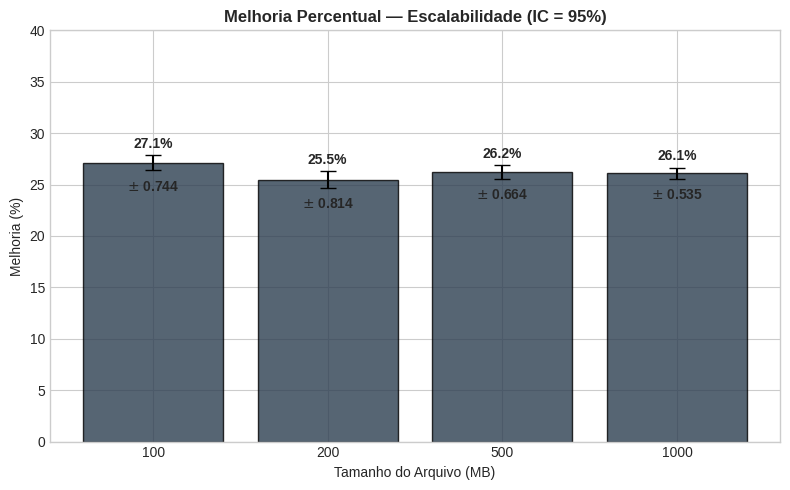

In [6]:
scalability_data = merged[merged['scenario'] == 'scalability'].copy()
plt.style.use('seaborn-v0_8-whitegrid')

x = np.arange(len(scalability_data))
labels = scalability_data['file_size_mb']

plt.figure(figsize=(8, 5))

bars = plt.bar(x, scalability_data['improvement'],
               yerr=scalability_data['improvement_ci'],
               capsize=6, color='#2c3e50', edgecolor='black', alpha=0.8)

plt.xticks(x, labels)
plt.xlabel('Tamanho do Arquivo (MB)')
plt.ylabel('Melhoria (%)')
plt.title('Melhoria Percentual — Escalabilidade (IC = 95%)', fontsize=12, fontweight='bold')
plt.ylim(0, 40)

for i, (y, ci) in enumerate(zip(scalability_data['improvement'], scalability_data['improvement_ci'])):
    plt.text(i, y + ci + 0.7, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')
    plt.text(i, y - ci - 2, rf'$\pm$ {ci:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_scal = df_agg[df_agg['scenario'] == 'scalability']

df_std_scal = df_scal[df_scal['algorithm'] == 'std'].sort_values('file_size_mb')
df_radix_scal = df_scal[df_scal['algorithm'] == 'radix'].sort_values('file_size_mb')

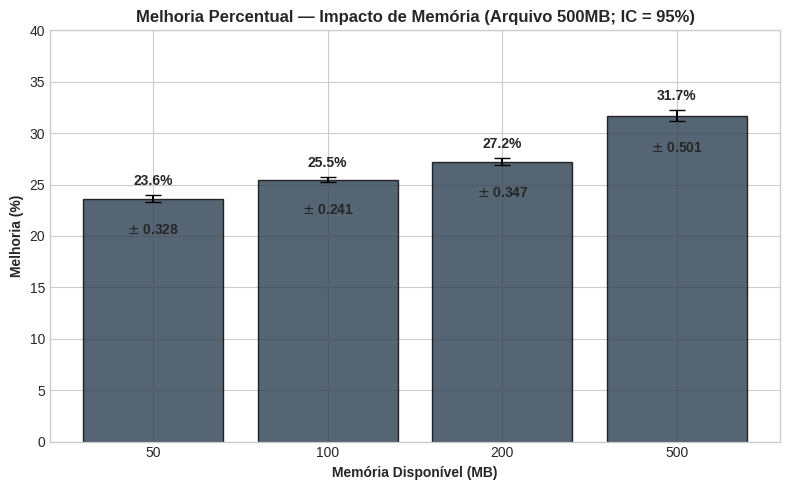

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')

memory_data = merged[merged['scenario'] == 'memory_impact'].copy()
x_indexes = np.arange(len(memory_data))
labels = memory_data['memory_mb']

plt.figure(figsize=(8, 5))

bars = plt.bar(x_indexes, memory_data['improvement'],
               yerr=memory_data['improvement_ci'],
               capsize=6, color='#2c3e50', edgecolor='black', alpha=0.8)

plt.xticks(x_indexes, labels)
plt.xlabel('Memória Disponível (MB)', fontweight='bold')
plt.ylabel('Melhoria (%)', fontweight='bold')
plt.title('Melhoria Percentual — Impacto de Memória (Arquivo 500MB; IC = 95%)', fontsize=12, fontweight='bold')
plt.ylim(0, 40)

for i, (y, ci) in enumerate(zip(memory_data['improvement'], memory_data['improvement_ci'])):
    plt.text(i, y + ci + 0.7, f'{y:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(i, y - ci - 2, rf'$\pm$ {ci:.3f}',
             ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
df_scal = df_agg[df_agg['scenario'] == 'scalability']
df_scal

,scenario,file_size_mb,memory_mb,algorithm,time_mean,time_std,run_count,throughput_mean,time_ci
8,scalability,100,100,radix,1.139879,0.043177,10,87.837352,0.026761
9,scalability,100,100,std,1.564450,0.035818,10,63.949548,0.022200
10,scalability,200,100,radix,2.437457,0.112699,10,82.203917,0.069852
11,scalability,200,100,std,3.271327,0.074473,10,61.165103,0.046159
12,scalability,500,100,radix,6.713210,0.146368,10,74.511543,0.090720
13,scalability,500,100,std,9.102331,0.314097,10,54.989606,0.194680
14,scalability,1000,100,radix,14.968970,0.280759,10,66.826210,0.174016
15,scalability,1000,100,std,20.260270,0.551846,10,49.392257,0.342038


In [9]:
df_std_scal = df_scal[df_scal['algorithm'] == 'std'].sort_values('file_size_mb')
df_std_scal

,scenario,file_size_mb,memory_mb,algorithm,time_mean,time_std,run_count,throughput_mean,time_ci
9,scalability,100,100,std,1.564450,0.035818,10,63.949548,0.022200
11,scalability,200,100,std,3.271327,0.074473,10,61.165103,0.046159
13,scalability,500,100,std,9.102331,0.314097,10,54.989606,0.194680
15,scalability,1000,100,std,20.260270,0.551846,10,49.392257,0.342038


In [10]:
df_radix_scal = df_scal[df_scal['algorithm'] == 'radix'].sort_values('file_size_mb')
df_radix_scal

,scenario,file_size_mb,memory_mb,algorithm,time_mean,time_std,run_count,throughput_mean,time_ci
8,scalability,100,100,radix,1.139879,0.043177,10,87.837352,0.026761
10,scalability,200,100,radix,2.437457,0.112699,10,82.203917,0.069852
12,scalability,500,100,radix,6.713210,0.146368,10,74.511543,0.090720
14,scalability,1000,100,radix,14.968970,0.280759,10,66.826210,0.174016


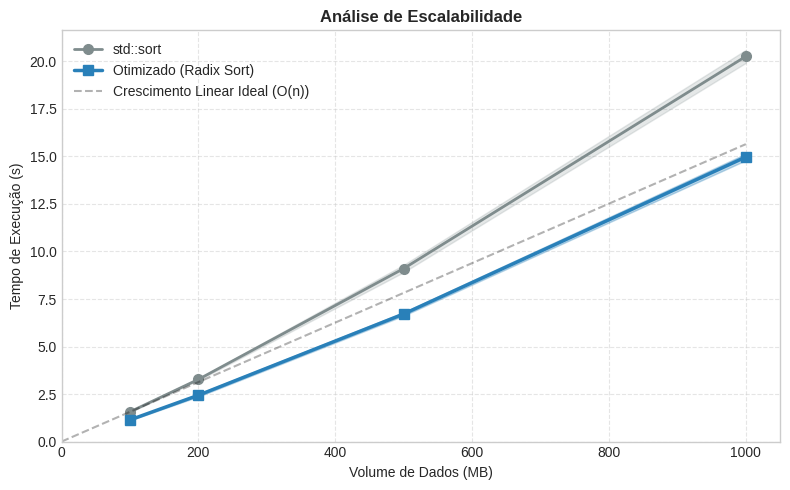

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

plt.plot(df_std_scal['file_size_mb'], df_std_scal['time_mean'], '-o',
         label='std::sort',
         color='#7f8c8d', linewidth=2, markersize=7)

plt.fill_between(df_std_scal['file_size_mb'],
                 df_std_scal['time_mean'] - df_std_scal['time_ci'],
                 df_std_scal['time_mean'] + df_std_scal['time_ci'],
                 color='#7f8c8d', alpha=0.2)

plt.plot(df_radix_scal['file_size_mb'], df_radix_scal['time_mean'], '-s',
         label='Otimizado (Radix Sort)',
         color='#2980b9', linewidth=2.5, markersize=7)

plt.fill_between(df_radix_scal['file_size_mb'],
                 df_radix_scal['time_mean'] - df_radix_scal['time_ci'],
                 df_radix_scal['time_mean'] + df_radix_scal['time_ci'],
                 color='#2980b9', alpha=0.3)

slope = df_std_scal['time_mean'].iloc[0] / df_std_scal['file_size_mb'].iloc[0]
x_ref = np.linspace(0, df_std_scal['file_size_mb'].max(), 100)
y_ref = slope * x_ref

plt.plot(x_ref, y_ref, '--', color='black', alpha=0.3,
         label='Crescimento Linear Ideal (O(n))')

plt.title('Análise de Escalabilidade', fontsize=12, fontweight='bold')
plt.xlabel('Volume de Dados (MB)')
plt.ylabel('Tempo de Execução (s)')

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

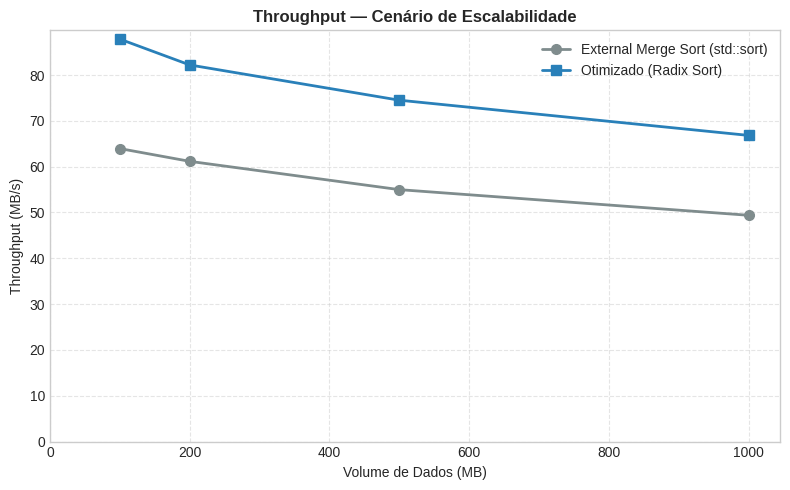

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

plt.plot(df_std_scal['file_size_mb'], df_std_scal['throughput_mean'], '-o',
         label='External Merge Sort (std::sort)', linewidth=2, color='#7f8c8d', markersize=7)

plt.plot(df_radix_scal['file_size_mb'], df_radix_scal['throughput_mean'], '-s',
         label='Otimizado (Radix Sort)', linewidth=2, color='#2980b9', markersize=7)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel('Volume de Dados (MB)')
plt.ylabel('Throughput (MB/s)')
plt.title('Throughput — Cenário de Escalabilidade', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Análise de Impacto na Memória

In [13]:
df_mem = df_agg[df_agg['scenario'] == 'memory_impact']

df_std_mem = df_mem[df_mem['algorithm'] == 'std'].sort_values('memory_mb')
df_radix_mem = df_mem[df_mem['algorithm'] == 'radix'].sort_values('memory_mb')

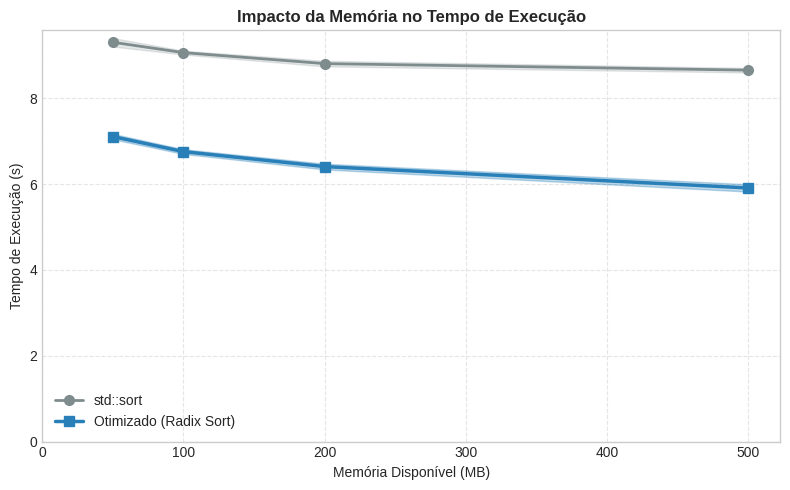

In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

plt.plot(df_std_mem['memory_mb'], df_std_mem['time_mean'], '-o',
         label='std::sort',
         color='#7f8c8d', linewidth=2, markersize=7)

plt.fill_between(df_std_mem['memory_mb'],
                 df_std_mem['time_mean'] - df_std_mem['time_ci'],
                 df_std_mem['time_mean'] + df_std_mem['time_ci'],
                 color='#7f8c8d', alpha=0.2)

plt.plot(df_radix_mem['memory_mb'], df_radix_mem['time_mean'], '-s',
         label='Otimizado (Radix Sort)',
         color='#2980b9', linewidth=2.5, markersize=7)

plt.fill_between(df_radix_mem['memory_mb'],
                 df_radix_mem['time_mean'] - df_radix_mem['time_ci'],
                 df_radix_mem['time_mean'] + df_radix_mem['time_ci'],
                 color='#2980b9', alpha=0.3)

plt.title('Impacto da Memória no Tempo de Execução',
          fontsize=12, fontweight='bold')

plt.xlabel('Memória Disponível (MB)')
plt.ylabel('Tempo de Execução (s)')

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

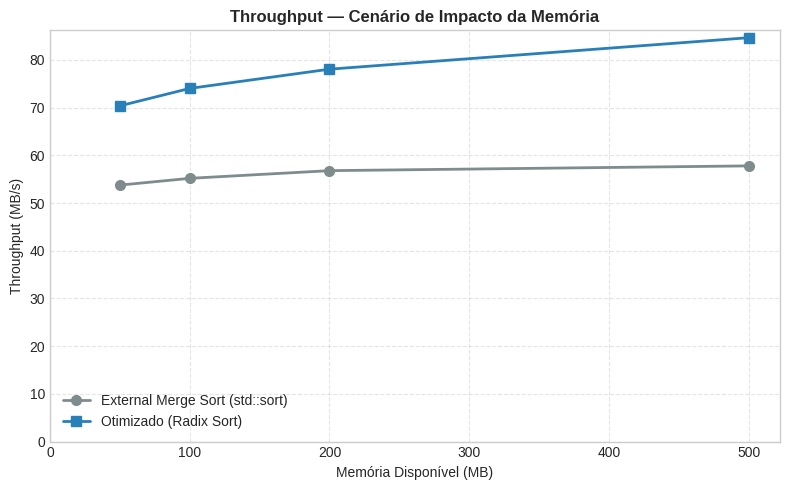

In [15]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

plt.plot(df_std_mem['memory_mb'], df_std_mem['throughput_mean'], '-o',
         label='External Merge Sort (std::sort)', linewidth=2,
         color='#7f8c8d', markersize=7)

plt.plot(df_radix_mem['memory_mb'], df_radix_mem['throughput_mean'], '-s',
         label='Otimizado (Radix Sort)', linewidth=2,
         color='#2980b9', markersize=7)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel('Memória Disponível (MB)')
plt.ylabel('Throughput (MB/s)')
plt.title('Throughput — Cenário de Impacto da Memória', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print("TESTE DE HIPÓTESE: std::sort vs Radix Sort")
print("H0: As médias de tempo de execução são iguais (Nenhum algoritmo é superior)")
print("H1: A média de tempo do Radix Sort é menor que a do std::sort\n")

grouped = df.groupby(['scenario', 'file_size_mb', 'memory_mb'])

for (scen, size, mem), group in grouped:
    std_times = group[group['algorithm'] == 'std']['time_sec'].values
    radix_times = group[group['algorithm'] == 'radix']['time_sec'].values

    t_stat, p_val = stats.ttest_ind(std_times, radix_times, equal_var=False)
    p_val_one_sided = p_val / 2
    significativo = "SIM" if p_val_one_sided < 0.05 else "NÃO"

    print(f"Cenário: {scen.upper()} | Tamanho: {size}MB | Mem: {mem}MB")
    print(f"  Média Std: {std_times.mean():.3f}s | Média Radix: {radix_times.mean():.3f}s")
    print(f"  P-Valor: {p_val_one_sided:.2e} -> Diferença Significativa? {significativo}\n")

TESTE DE HIPÓTESE: std::sort vs Radix Sort
H0: As médias de tempo de execução são iguais (Nenhum algoritmo é superior)
H1: A média de tempo do Radix Sort é menor que a do std::sort

Cenário: MEMORY_IMPACT | Tamanho: 500MB | Mem: 50MB
  Média Std: 9.302s | Média Radix: 7.105s
  P-Valor: 1.29e-16 -> Diferença Significativa? SIM

Cenário: MEMORY_IMPACT | Tamanho: 500MB | Mem: 100MB
  Média Std: 9.061s | Média Radix: 6.755s
  P-Valor: 2.57e-22 -> Diferença Significativa? SIM

Cenário: MEMORY_IMPACT | Tamanho: 500MB | Mem: 200MB
  Média Std: 8.805s | Média Radix: 6.407s
  P-Valor: 3.88e-21 -> Diferença Significativa? SIM

Cenário: MEMORY_IMPACT | Tamanho: 500MB | Mem: 500MB
  Média Std: 8.652s | Média Radix: 5.909s
  P-Valor: 7.77e-19 -> Diferença Significativa? SIM

Cenário: SCALABILITY | Tamanho: 100MB | Mem: 100MB
  Média Std: 1.564s | Média Radix: 1.140s
  P-Valor: 4.59e-15 -> Diferença Significativa? SIM

Cenário: SCALABILITY | Tamanho: 200MB | Mem: 100MB
  Média Std: 3.271s | Média Ra

In [19]:
df_mem_runs = df[df['scenario'] == 'memory_impact'].groupby(['memory_mb', 'algorithm'])['total_runs'].first().reset_index()

In [20]:
df_std_runs = df_mem_runs[df_mem_runs['algorithm'] == 'std'].sort_values('memory_mb')

In [22]:
df_radix_runs = df_mem_runs[df_mem_runs['algorithm'] == 'radix'].sort_values('memory_mb')

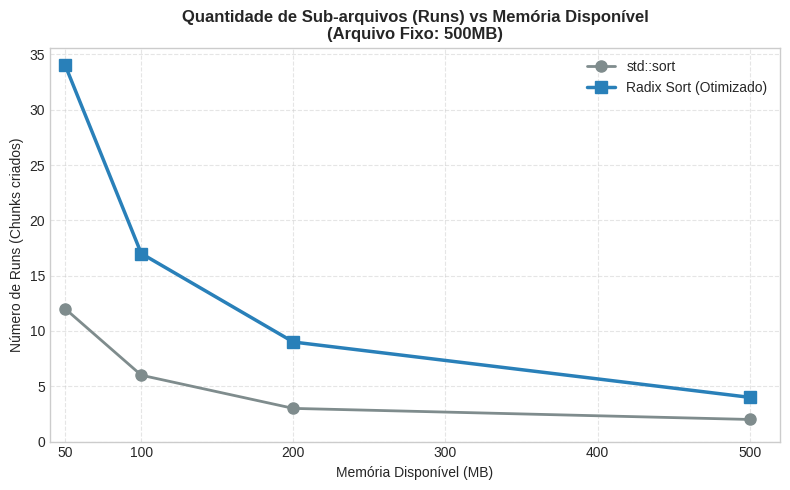

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

plt.plot(df_std_runs['memory_mb'], df_std_runs['total_runs'], '-o',
         label='std::sort', color='#7f8c8d', linewidth=2, markersize=8)

plt.plot(df_radix_runs['memory_mb'], df_radix_runs['total_runs'], '-s',
         label='Radix Sort (Otimizado)', color='#2980b9', linewidth=2.5, markersize=8)

plt.title('Quantidade de Sub-arquivos (Runs) vs Memória Disponível\n(Arquivo Fixo: 500MB)',
          fontsize=12, fontweight='bold')

plt.xlabel('Memória Disponível (MB)')
plt.ylabel('Número de Runs (Chunks criados)')

plt.xticks([50, 100, 200, 300, 400, 500])
plt.xlim(40, 520)
plt.ylim(0, None)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()